Import Libraries

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import hydroeval as he

Model Library

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import SGD,RMSprop,Adam,Adadelta,Adagrad,Adamax,Nadam

Hyper Parameter Tuner

In [15]:
import keras_tuner as kt
import time

# Model Checkpoint

from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError,MeanAbsoluteError
from tensorflow.keras.metrics import RootMeanSquaredError

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load Dataset

In [18]:
df = pd.read_csv('preprocessed_dataset_kathmandu.csv',index_col=0)

In [19]:
df.head()

,PM2.5,O3,TEMPERATURE,PRESSURE,DEWPOINT,RAIN
date_and_time,,,,,,
2019-01-01 00:00:00,0.098577,0.000000,0.060150,0.814545,0.243077,0.0
2019-01-01 01:00:00,0.114837,0.000000,0.112782,0.847273,0.243077,0.0
2019-01-01 02:00:00,0.137195,0.008475,0.150376,0.880000,0.264615,0.0
2019-01-01 03:00:00,0.178862,0.033898,0.285714,0.909091,0.332308,0.0
2019-01-01 04:00:00,0.197154,0.161017,0.394737,0.916364,0.252308,0.0


In [21]:
features = ["PM2.5","O3","TEMPERATURE","PRESSURE","DEWPOINT","RAIN"]
df = df[features]

In [22]:
mean_pm = df['PM2.5'].mean()
std_pm = df['PM2.5'].std()
z_scores = (df['PM2.5'] - mean_pm) / std_pm
threshold = 3
df = df[np.abs(z_scores) < threshold]

Adding Window 

In [23]:

def df_to_X_y(df, window_size = 5):
    df_as_np = df.to_numpy()
    X = []
    y = []
    for i in range(len(df_as_np)-window_size):
        row = [r for r in df_as_np[i:i+window_size]]
        X.append(row)
        label = df_as_np[i+window_size][0]
        y.append(label)
    return np.array(X), np.array(y)

WINDOW_SIZE = 2

X, y = df_to_X_y(df,WINDOW_SIZE)

X.shape, y.shape    

((7564, 2, 6), (7564,))

Import

In [24]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid

from tensorflow import keras
from tensorflow.keras import layers

Developing Transformer Model

In [25]:

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    
    # Normalization and Attention
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    # Feed Forward Part
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res

from tensorflow.keras.callbacks import EarlyStopping

def build_model(hp):
    inputs = keras.Input(shape=input_shape)
    x = inputs

    for i in range(hp.Int('num_transformer_blocks', min_value=2, max_value=8, step=2)):
        x = transformer_encoder(x,
                               hp.Int('head_size', min_value=8, max_value=256, step=32),
                               hp.Int('num_heads', min_value=2, max_value=16),
                               hp.Int('ff_dim', min_value=4, max_value=64),
                               hp.Float(f'dropout_{i}', min_value=0.1, max_value=0.6))

    x = layers.GlobalAveragePooling1D(data_format="channels_first")(x)

    for i in range(hp.Int('num_mlp_layers', min_value=1, max_value=3)):
        x = layers.Dense(hp.Int(f'mlp_units_{i}', min_value=32, max_value=256, step=32))(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(hp.Float(f'mlp_dropout_{i}', min_value=0.1, max_value=0.6))(x)

    outputs = layers.Dense(1)(x)
    model = keras.Model(inputs, outputs)

    # Choose optimizer and learning rate
    optimizer = hp.Choice('optimizer', values=['adam', 'adamax'])
    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2)

    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    else:
        opt = Adamax(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999)

    model.compile(optimizer=opt, loss=MeanSquaredError(), metrics=['mae', RootMeanSquaredError()])

    return model

In [26]:
input_shape = X.shape[1:]
input_shape

(2, 6)

importing for training

In [28]:
from sklearn.model_selection import KFold
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters
import keras_tuner as kt

Model Building

In [29]:

# Define your input shape
input_shape = X.shape[1:]


# Assume you have your data X and y
best_model_hyperparameters = None
best_model_mae = float('inf')

worst_model_hyperparameters = None
worst_model_mae = float('-inf')

# Initialize K-Fold cross-validation for the outer loop
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)


# Perform Nested Cross-Validation
nested_scores = []

for fold_outer_idx, (train_ix, test_ix) in enumerate(outer_cv.split(X)):
    X_train_outer, X_test_outer = X[train_ix], X[test_ix]
    y_train_outer, y_test_outer = y[train_ix], y[test_ix]

    # Inner loop for hyperparameter tuning
    inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

    for fold_idx, (train_ix_inner, val_ix) in enumerate(inner_cv.split(X_train_outer)):
        X_train_inner, X_val = X_train_outer[train_ix_inner], X_train_outer[val_ix]
        y_train_inner, y_val = y_train_outer[train_ix_inner], y_train_outer[val_ix]

        tuner = kt.RandomSearch(
            build_model,
            objective='val_loss',
            max_trials=5,
            # directory=f'C:\Users\Acer\Desktop\TR tuner val/keras_tuner_random_dir_fold_tf_{fold_outer_idx}_{fold_idx}',
            # project_name=f'C:\Users\Acer\Desktop\TR tuner val/hyperparameter_random_tuning_fold_tf_{fold_outer_idx}_{fold_idx}'
            
            #directory=f'/content/drive/MyDrive/research/keras_tuner_random_dir_fold_tf_{fold_outer_idx}_{fold_idx}',
            #project_name=f'/content/drive/MyDrive/research/hyperparameter_random_tuning_fold_tf_{fold_outer_idx}_{fold_idx}'
            directory = f'C:/Users/Administrator/Documents/GitHub/AQI_Forecasting/Hp_Tr_Kathmandu/keras_tuner_random_dir_fold_tf_{fold_outer_idx}_{fold_idx}',
            project_name = f'C:/Users/Administrator/Documents/GitHub/AQI_Forecasting/Hp_Tr_Kathmandu/hyperparameter_random_tuning_fold_tf_{fold_outer_idx}_{fold_idx}'
        )

        # Search for the best hyperparameters
        tuner.search(X_train_inner, y_train_inner, validation_data=(X_val, y_val), epochs=30)

        # tuner.search(X_train_inner, y_train_inner, validation_data=(X_val, y_val), epochs=30)  # Adjust epochs as needed
        best_hps = tuner.oracle.get_best_trials(1)[0].hyperparameters
        print(f"Best hyperparameters for fold {fold_idx}: {best_hps}")

        model = build_model(best_hps)
        es = [keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]

        model.fit(
            X_train_inner,
            y_train_inner,
            validation_data=(X_val, y_val),
            epochs=10,
            batch_size=32,
            callbacks=[es],
        )

        y_pred = model.predict(X_val)
        mae = mean_squared_error(y_val, y_pred)

         # Update best model
        if mae < best_model_mae:
            best_model_mae = mae
            best_model_hyperparameters = best_hps
            best_model = model

        # Update worst model
        if mae > worst_model_mae:
            worst_model_mae = mae
            worst_model_hyperparameters = best_hps
            worst_model = model

    # Now that we have the best and worst models, evaluate them on the test set
    start_time = time.time()
    y_pred_best = best_model.predict(X_test_outer)
    y_pred_worst = worst_model.predict(X_test_outer)
    end_time = time.time()

    mse_best = mean_squared_error(y_test_outer, y_pred_best)
    mae_best = mean_absolute_error(y_test_outer, y_pred_best)
    rmse_best = np.sqrt(mse_best)

    nse_best = he.evaluator(he.nse, y_pred_best, y_test_outer)
    kge_best, r, alpha, beta = he.evaluator(he.kge, y_pred_best, y_test_outer)
    print("Best Model:")
    print("KGE : ", kge_best)

    r2_best = r2_score(y_test_outer, y_pred_best)
    time_duration = end_time - start_time

    mse_worst = mean_squared_error(y_test_outer, y_pred_worst)
    mae_worst = mean_absolute_error(y_test_outer, y_pred_worst)
    rmse_worst = np.sqrt(mse_worst)

    nse_worst = he.evaluator(he.nse, y_pred_worst, y_test_outer)
    kge_worst, r, alpha, beta = he.evaluator(he.kge, y_pred_worst, y_test_outer)
    print("Worst Model:")
    print("KGE : ", kge_worst)

    r2_worst = r2_score(y_test_outer, y_pred_worst)
    time_duration = end_time - start_time

    nested_scores.append({
        "Best Model": {
            "MSE": mse_best,
            "R^2": r2_best,
            "RMSE": rmse_best,
            "MAE": mae_best,
            "testing time": time_duration,
            "nse": nse_best,
            "kge": kge_best
        },
        "Worst Model": {
            "MSE": mse_worst,
            "R^2": r2_worst,
            "RMSE": rmse_worst,
            "MAE": mae_worst,
            "testing time": time_duration,
            "nse": nse_worst,
            "kge": kge_worst
        }
    })

# Save the best and worst hyperparameters
print("Best Hyperparameters:", best_model_hyperparameters)
print("Best MAE:", best_model_mae)

print("Worst Hyperparameters:", worst_model_hyperparameters)
print("Worst MAE:", worst_model_mae)


# Print or use the nested_scores as needed
print("Nested Cross-Validation Scores:")
for i, scores in enumerate(nested_scores):
    print(f"\nFold {i + 1} - MSE: {scores['Best Model']['MSE']}, R^2: {scores['Best Model']['R^2']}, RMSE: {scores['Best Model']['RMSE']}, MAE: {scores['Best Model']['MAE']}, kge: {scores['Best Model']['kge']}, nse: {scores['Best Model']['nse']}")

Reloading Tuner from C:/Users/Administrator/Documents/GitHub/AQI_Forecasting/Hp_Tr_Kathmandu/hyperparameter_random_tuning_fold_tf_0_0\tuner0.json
Best hyperparameters for fold 0: <keras_tuner.src.engine.hyperparameters.hyperparameters.HyperParameters object at 0x00000260445C8B90>
Epoch 1/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.0038 - mae: 0.0442 - root_mean_squared_error: 0.0598 - val_loss: 0.0013 - val_mae: 0.0265 - val_root_mean_squared_error: 0.0366
Epoch 2/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0012 - mae: 0.0273 - root_mean_squared_error: 0.0353 - val_loss: 0.0011 - val_mae: 0.0238 - val_root_mean_squared_error: 0.0327
Epoch 3/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0011 - mae: 0.0252 - root_mean_squared_error: 0.0328 - val_loss: 7.7738e-04 - val_mae: 0.0204 - val_root_mean_squared_error: 0.0279
Epoch 4/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 9.6487e-04 - mae: 0.0235 - root_mean_squared_error: 0.0310 - val_loss: 6.0333e-0

In [30]:
history = model.fit(
            X_train_inner,
            y_train_inner,
            validation_data=(X_val, y_val),
            epochs=10,
            batch_size=32,
            callbacks=[es],
        )

Epoch 1/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.5058e-04 - mae: 0.0136 - root_mean_squared_error: 0.0187 - val_loss: 0.0011 - val_mae: 0.0247 - val_root_mean_squared_error: 0.0335
Epoch 2/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.1311e-04 - mae: 0.0217 - root_mean_squared_error: 0.0284 - val_loss: 4.1973e-04 - val_mae: 0.0160 - val_root_mean_squared_error: 0.0205
Epoch 3/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.8583e-04 - mae: 0.0160 - root_mean_squared_error: 0.0220 - val_loss: 3.0304e-04 - val_mae: 0.0118 - val_root_mean_squared_error: 0.0174
Epoch 4/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.5746e-04 - mae: 0.0134 - root_mean_squared_error: 0.0189 - val_loss: 2.8920e-04 - val_mae: 0.0118 - val_root_mean_squared_error: 0.0170
Epoch 5/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8634e-04 - mae: 0.0137 - root_mean_squared_error: 0.0196 - val_loss: 3.1368e-04 - val_mae: 0.0121 - val_root_mean_squared_error: 0.0177
Epoch 6/1

Nested Cross Validation Scores

In [33]:
print("Nested Cross-Validation Scores:")
for i, scores in enumerate(nested_scores):
    print(f"\nFold {i + 1} - MSE: {scores['Worst Model']['MSE']}, R^2: {scores['Worst Model']['R^2']}, RMSE: {scores['Worst Model']['RMSE']}, MAE: {scores['Worst Model']['MAE']}, kge: {scores['Worst Model']['kge']}, nse: {scores['Worst Model']['nse']}, time: {scores['Worst Model']['testing time']}")

# Calculate overall statistics
all_mse = [scores['Worst Model']['MSE'] for scores in nested_scores]
all_mae = [scores['Worst Model']['MAE'] for scores in nested_scores]
all_rsme = [scores['Worst Model']['RMSE'] for scores in nested_scores]
all_r2 = [scores['Worst Model']['R^2'] for scores in nested_scores]
all_kge = [scores['Worst Model']['kge'] for scores in nested_scores]
all_nse = [scores['Worst Model']['nse'] for scores in nested_scores]
all_time = [scores['Worst Model']['testing time'] for scores in nested_scores]
mean_mse = np.mean(all_mse)
mean_mae = np.mean(all_mae)
mean_rsme = np.mean(all_rsme)
mean_r2 = np.mean(all_r2)
mean_kge = np.mean(all_kge)
mean_nse = np.mean(all_nse)
mean_time = np.mean(all_time)

print(f"Mean MSE: {mean_mse:.3f}")
print(f"Mean MAE: {mean_mae:.3f}")
print(f"Mean RMSE: {mean_rsme:.3f}")
print(f"Mean R^2: {mean_r2:.3f}")
print(f"Mean kge: {mean_kge:.3f}")
print(f"Mean nse: {mean_nse:.3f}")
print(f"Mean time: {mean_time:.3f}")

Nested Cross-Validation Scores:

Fold 1 - MSE: 0.0006933543563018603, R^2: 0.393297759524711, RMSE: 0.02633162274342127, MAE: 0.019965671900492483, kge: [0.43482021], nse: [0.39329776], time: 0.5800533294677734

Fold 2 - MSE: 0.0006260699487559266, R^2: 0.4251457871212013, RMSE: 0.02502138982462658, MAE: 0.019076995386799734, kge: [0.45694348], nse: [0.42514579], time: 0.739220142364502

Fold 3 - MSE: 0.0007187088046407377, R^2: 0.3388965692996122, RMSE: 0.026808744928488122, MAE: 0.020401949366853526, kge: [0.30075481], nse: [0.33889657], time: 0.561208963394165

Fold 4 - MSE: 0.0008154835792708282, R^2: 0.2458688098092342, RMSE: 0.028556673112791486, MAE: 0.02146803323308178, kge: [0.19022431], nse: [0.24586881], time: 1.2512719631195068

Fold 5 - MSE: 0.0007967989384956261, R^2: 0.24565385686778063, RMSE: 0.028227627220431158, MAE: 0.02098210626841265, kge: [0.18621337], nse: [0.24565386], time: 1.166015625
Mean MSE: 0.001
Mean MAE: 0.020
Mean RMSE: 0.027
Mean R^2: 0.330
Mean kge: 0

Using Nested_scores as needed

In [34]:
# Print or use the nested_scores as needed
print("Nested Cross-Validation Scores:")
for i, scores in enumerate(nested_scores):
    print(f"\nFold {i + 1} - MSE: {scores['Best Model']['MSE']}, R^2: {scores['Best Model']['R^2']}, RMSE: {scores['Best Model']['RMSE']}, MAE: {scores['Best Model']['MAE']}, kge: {scores['Best Model']['kge']}, nse: {scores['Best Model']['nse']}")

# Calculate overall statistics
all_mse = [scores['Best Model']['MSE'] for scores in nested_scores]
all_mae = [scores['Best Model']['MAE'] for scores in nested_scores]
all_rsme = [scores['Best Model']['RMSE'] for scores in nested_scores]
all_r2 = [scores['Best Model']['R^2'] for scores in nested_scores]
all_kge = [scores['Best Model']['kge'] for scores in nested_scores]
all_nse = [scores['Best Model']['nse'] for scores in nested_scores]
all_time = [scores['Best Model']['testing time'] for scores in nested_scores]
mean_mse = np.mean(all_mse)
mean_mae = np.mean(all_mae)
mean_rsme = np.mean(all_rsme)
mean_r2 = np.mean(all_r2)
mean_kge = np.mean(all_kge)
mean_nse = np.mean(all_nse)
mean_time = np.mean(all_time)

print(f"Mean MSE: {mean_mse:.6f}")
print(f"Mean MAE: {mean_mae:.6f}")
print(f"Mean RMSE: {mean_rsme:.6f}")
print(f"Mean R^2: {mean_r2:.6f}")
print(f"Mean kge: {mean_kge:.6f}")
print(f"Mean nse: {mean_nse:.6f}")
print(f"Mean time: {mean_time:.6f}")


Nested Cross-Validation Scores:

Fold 1 - MSE: 0.0003594138411567486, R^2: 0.6855039840656959, RMSE: 0.018958213026462927, MAE: 0.01307652458189907, kge: [0.60864397], nse: [0.68550398]

Fold 2 - MSE: 0.00027425156233176474, R^2: 0.7481836233981755, RMSE: 0.016560542332054368, MAE: 0.011737669264876726, kge: [0.75455178], nse: [0.74818362]

Fold 3 - MSE: 0.00031318369975267987, R^2: 0.7119183499505982, RMSE: 0.01769699691339409, MAE: 0.012154299648611115, kge: [0.69998416], nse: [0.71191835]

Fold 4 - MSE: 0.0002563721624663044, R^2: 0.7629158343257266, RMSE: 0.01601162585330748, MAE: 0.011032645062864409, kge: [0.75204798], nse: [0.76291583]

Fold 5 - MSE: 0.0002831672885067774, R^2: 0.7319196328880795, RMSE: 0.01682757524145346, MAE: 0.011164578616705213, kge: [0.73676305], nse: [0.73191963]
Mean MSE: 0.000297
Mean MAE: 0.011833
Mean RMSE: 0.017211
Mean R^2: 0.728088
Mean kge: 0.710398
Mean nse: 0.728088
Mean time: 0.859554


Graph Plotting

237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


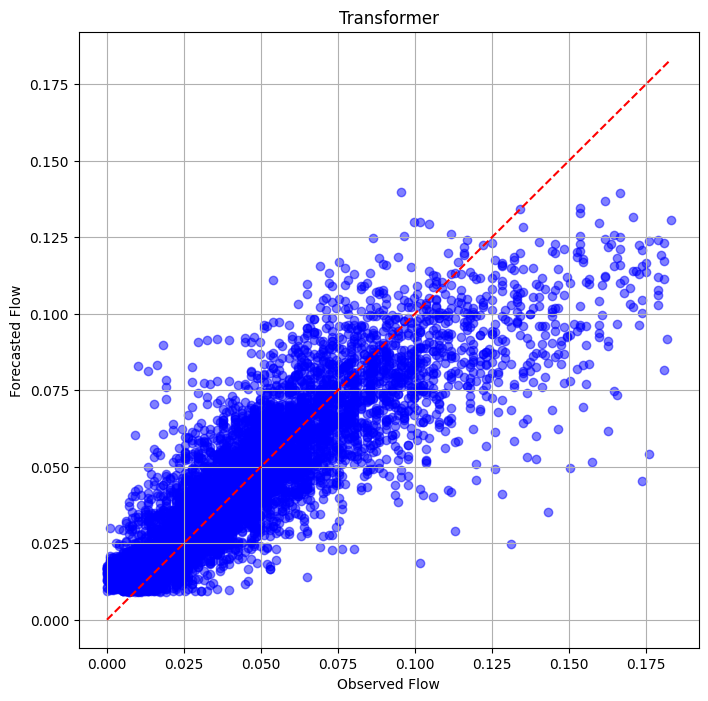

In [35]:
import matplotlib.pyplot as plt

# Assuming you have arrays y_pred and y_observed
# y_pred and y_observed should have the same length
y_pred = best_model.predict(X).flatten()
y_observed = y
plt.figure(figsize=(8, 8))
plt.scatter(y_observed, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_observed), max(y_observed)], [min(y_observed), max(y_observed)], color='red', linestyle='--')
plt.title('Transformer')
plt.xlabel('Observed Flow')
plt.ylabel('Forecasted Flow')
plt.grid(True)
plt.show()

In [ ]:
best_model.save(r'C:/Users/Administrator/Documents/GitHub/AQI_Forecasting/best_model_transformer_4i.h5')

Optimizer Test

In [36]:
# Assuming best_model is your trained model
optimizer = best_model.optimizer
learning_rate = float(optimizer.learning_rate.numpy())

# Print the optimizer and learning rate
print("Optimizer:", type(optimizer).__name__)
print("Learning Rate:", learning_rate)

Optimizer: Adam
Learning Rate: 0.003880788804963231


In [37]:
# Assuming best_model is your trained model

# Function to extract dropout rate from a layer
def get_dropout_rate(layer):
    if hasattr(layer, 'rate'):
        return layer.rate
    elif hasattr(layer, 'dropout'):
        return layer.dropout
    else:
        return None

# Iterate through layers of the model and find the dropout rates
dropout_rates = []

for layer in best_model.layers:
    rate = get_dropout_rate(layer)
    if rate is not None:
        dropout_rates.append((layer.name, rate))

# Print the dropout rates
print("Dropout Rates:")
for layer_name, rate in dropout_rates:
    print(f"{layer_name}: {rate}")

Dropout Rates:
multi_head_attention_46: 0.12517664424159622
dropout_162: 0.12517664424159622
dropout_163: 0.12517664424159622
multi_head_attention_47: 0.43943695531364113
dropout_165: 0.43943695531364113
dropout_166: 0.43943695531364113
dropout_167: 0.22228474945334928


In [38]:
best_hyperparameters_dict = best_model_hyperparameters.values
worst_hyperparameters_dict = worst_model_hyperparameters.values

print("Best Hyperparameters:", best_hyperparameters_dict)
print("Worst Hyperparameters:", worst_hyperparameters_dict)

Best Hyperparameters: {'num_transformer_blocks': 2, 'head_size': 232, 'num_heads': 12, 'ff_dim': 7, 'dropout_0': 0.12517664424159622, 'dropout_1': 0.43943695531364113, 'num_mlp_layers': 1, 'mlp_units_0': 128, 'mlp_dropout_0': 0.22228474945334928, 'optimizer': 'adam', 'learning_rate': 0.0038807889105919296, 'dropout_2': 0.29448219985311175, 'dropout_3': 0.3014658438806256, 'dropout_4': 0.5441204819872223, 'dropout_5': 0.15309876617873266, 'dropout_6': 0.2705034131987628, 'dropout_7': 0.5684304462055615, 'mlp_units_1': 224, 'mlp_dropout_1': 0.5276796636482048}
Worst Hyperparameters: {'num_transformer_blocks': 8, 'head_size': 8, 'num_heads': 10, 'ff_dim': 25, 'dropout_0': 0.5555703441031121, 'dropout_1': 0.37946237801578975, 'num_mlp_layers': 2, 'mlp_units_0': 160, 'mlp_dropout_0': 0.30580870824364126, 'optimizer': 'adam', 'learning_rate': 0.002386324017945027, 'dropout_2': 0.1982692059939157, 'dropout_3': 0.10273585443270497, 'dropout_4': 0.18699135688150167, 'dropout_5': 0.2905727494594

In [ ]:
# from keras.utils import plot_model
# # Visualize the model architecture and save the diagram to a file
# plot_model(best_model, to_file='tf_model.png', show_shapes=True, show_layer_names=True

In [39]:
# Assuming best_model is your trained model

# Function to extract dropout rate from a layer
def get_dropout_rate(layer):
    if hasattr(layer, 'rate'):
        return layer.rate
    elif hasattr(layer, 'dropout'):
        return layer.dropout
    else:
        return None

# Iterate through layers of the model and find the dropout rates
dropout_rates = []

for layer in best_model.layers:
    rate = get_dropout_rate(layer)
    if rate is not None:
        dropout_rates.append((layer.name, rate))

# Print the dropout rates
print("Dropout Rates:")
for layer_name, rate in dropout_rates:
    print(f"{layer_name}: {rate}")

Dropout Rates:
multi_head_attention_46: 0.12517664424159622
dropout_162: 0.12517664424159622
dropout_163: 0.12517664424159622
multi_head_attention_47: 0.43943695531364113
dropout_165: 0.43943695531364113
dropout_166: 0.43943695531364113
dropout_167: 0.22228474945334928


In [40]:
# Print or use the nested_scores as needed
print("Nested Cross-Validation Scores:")
for i, scores in enumerate(nested_scores):
    print(f"\nFold {i + 1} - MSE: {scores['Best Model']['MSE']}, R^2: {scores['Best Model']['R^2']}, RMSE: {scores['Best Model']['RMSE']}, MAE: {scores['Best Model']['MAE']}, kge: {scores['Best Model']['kge']}, nse: {scores['Best Model']['nse']}")


# Calculate overall statistics
all_mse = [scores['Best Model']['MSE'] for scores in nested_scores]
all_mae = [scores['Best Model']['MAE'] for scores in nested_scores]
all_rsme = [scores['Best Model']['RMSE'] for scores in nested_scores]
all_r2 = [scores['Best Model']['R^2'] for scores in nested_scores]
all_kge = [scores['Best Model']['kge'] for scores in nested_scores]
all_nse = [scores['Best Model']['nse'] for scores in nested_scores]
all_time = [scores['Best Model']['testing time'] for scores in nested_scores]
mean_mse = np.mean(all_mse)
mean_mae = np.mean(all_mae)
mean_rsme = np.mean(all_rsme)
mean_r2 = np.mean(all_r2)
mean_kge = np.mean(all_kge)
mean_nse = np.mean(all_nse)
mean_time = np.mean(all_time)

print(f"Mean MSE: {mean_mse:.3f}")
print(f"Mean MAE: {mean_mae:.3f}")
print(f"Mean RMSE: {mean_rsme:.3f}")
print(f"Mean R^2: {mean_r2:.3f}")
print(f"Mean kge: {mean_kge:.3f}")
print(f"Mean nse: {mean_nse:.3f}")
print(f"Mean time: {mean_time:.3f}")

Nested Cross-Validation Scores:

Fold 1 - MSE: 0.0003594138411567486, R^2: 0.6855039840656959, RMSE: 0.018958213026462927, MAE: 0.01307652458189907, kge: [0.60864397], nse: [0.68550398]

Fold 2 - MSE: 0.00027425156233176474, R^2: 0.7481836233981755, RMSE: 0.016560542332054368, MAE: 0.011737669264876726, kge: [0.75455178], nse: [0.74818362]

Fold 3 - MSE: 0.00031318369975267987, R^2: 0.7119183499505982, RMSE: 0.01769699691339409, MAE: 0.012154299648611115, kge: [0.69998416], nse: [0.71191835]

Fold 4 - MSE: 0.0002563721624663044, R^2: 0.7629158343257266, RMSE: 0.01601162585330748, MAE: 0.011032645062864409, kge: [0.75204798], nse: [0.76291583]

Fold 5 - MSE: 0.0002831672885067774, R^2: 0.7319196328880795, RMSE: 0.01682757524145346, MAE: 0.011164578616705213, kge: [0.73676305], nse: [0.73191963]
Mean MSE: 0.000
Mean MAE: 0.012
Mean RMSE: 0.017
Mean R^2: 0.728
Mean kge: 0.710
Mean nse: 0.728
Mean time: 0.860


In [41]:
# Assuming best_model is your trained model
optimizer = best_model.optimizer
learning_rate = float(optimizer.learning_rate.numpy())

# Print the optimizer and learning rate
print("Optimizer:", type(optimizer).__name__)
print("Learning Rate:", learning_rate)    

Optimizer: Adam
Learning Rate: 0.003880788804963231


In [28]:
# Assuming best_model is your final trained model
best_model.save(r'C:/Users/Administrator/Documents/GitHub/AQI_Forecasting/best_model_transformer.h5')

237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


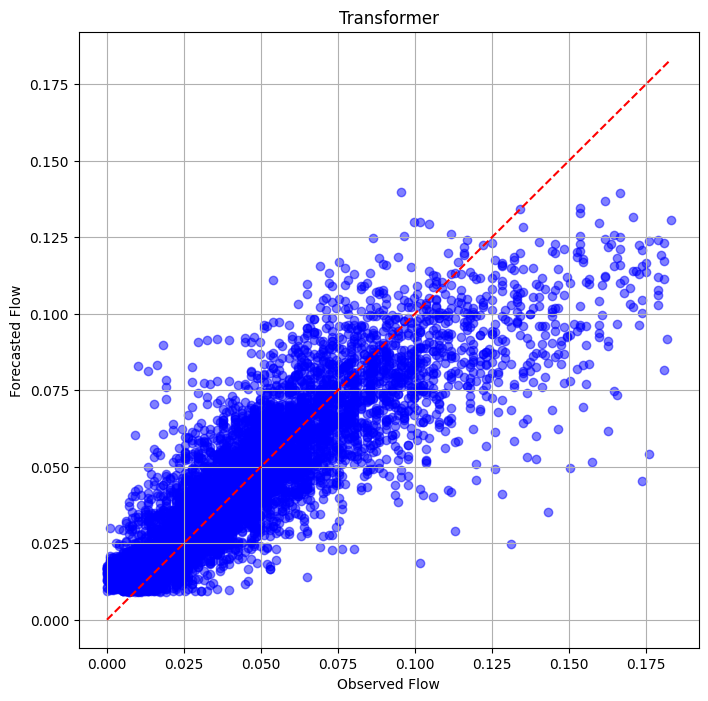

In [42]:
import matplotlib.pyplot as plt

# Assuming you have arrays y_pred and y_observed
# y_pred and y_observed should have the same length
y_pred = best_model.predict(X).flatten()
y_observed = y
plt.figure(figsize=(8, 8))
plt.scatter(y_observed, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_observed), max(y_observed)], [min(y_observed), max(y_observed)], color='red', linestyle='--')
plt.title('Transformer')
plt.xlabel('Observed Flow')
plt.ylabel('Forecasted Flow')
plt.grid(True)
plt.show()

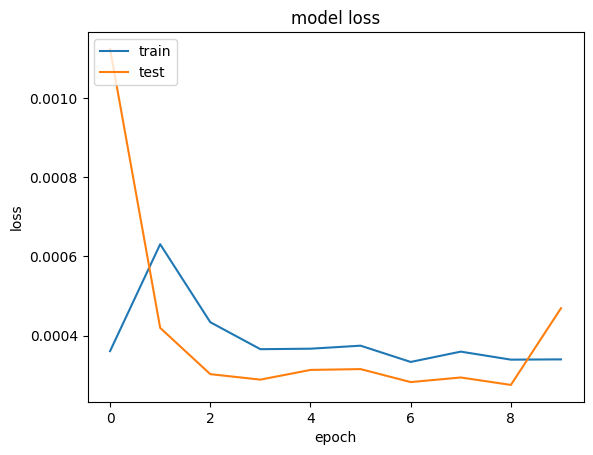

In [43]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

100 days

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


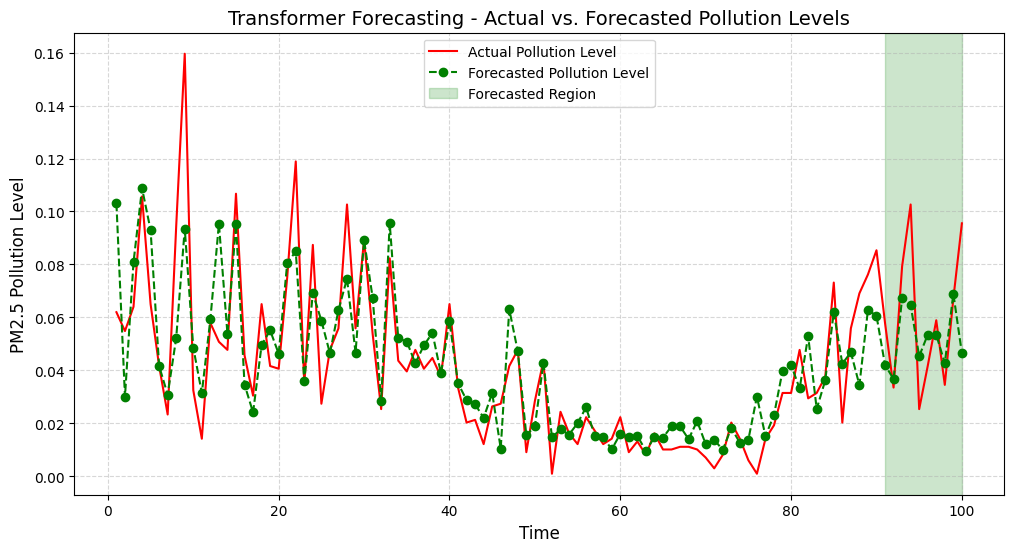

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Generate forecasted values using the best model
y_pred_best = best_model.predict(X_test_outer)

# Select 100 evenly spaced indices from the test set
num_points = 100
indices = np.linspace(0, len(y_test_outer) - 1, num_points, dtype=int)

# Subset the actual and forecasted values
time_steps = np.linspace(1, 100, num_points)  # Scale x-axis to 100 days
y_test_sampled = y_test_outer[indices]
y_pred_sampled = y_pred_best[indices]

# Define the forecasted region (last 10 points)
forecast_start = num_points - 10  # Last 10 points
forecast_x = time_steps[forecast_start:]
forecast_y_actual = y_test_sampled[forecast_start:]
forecast_y_pred = y_pred_sampled[forecast_start:]

# Plot actual pollution level in red
plt.figure(figsize=(12, 6))
plt.plot(time_steps, y_test_sampled, label="Actual Pollution Level", color="red", linestyle='solid', linewidth=1.5)

# Plot forecasted pollution level in green dashed line with markers
plt.plot(time_steps, y_pred_sampled, label="Forecasted Pollution Level", color="green", linestyle='dashed', marker='o', linewidth=1.5)

# Highlight forecasted region in shaded green
plt.axvspan(forecast_x[0], forecast_x[-1], color='green', alpha=0.2, label="Forecasted Region")

# Labels and title
plt.xlabel("Time", fontsize=12)
plt.ylabel("PM2.5 Pollution Level", fontsize=12)
plt.title("Transformer Forecasting - Actual vs. Forecasted Pollution Levels", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


C:\Users\Administrator\AppData\Local\Temp\ipykernel_10652\3008471445.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  input_data[0, -1, 0] = next_pred  # Replace last value with new prediction (assumes PM2.5 is at index 0)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


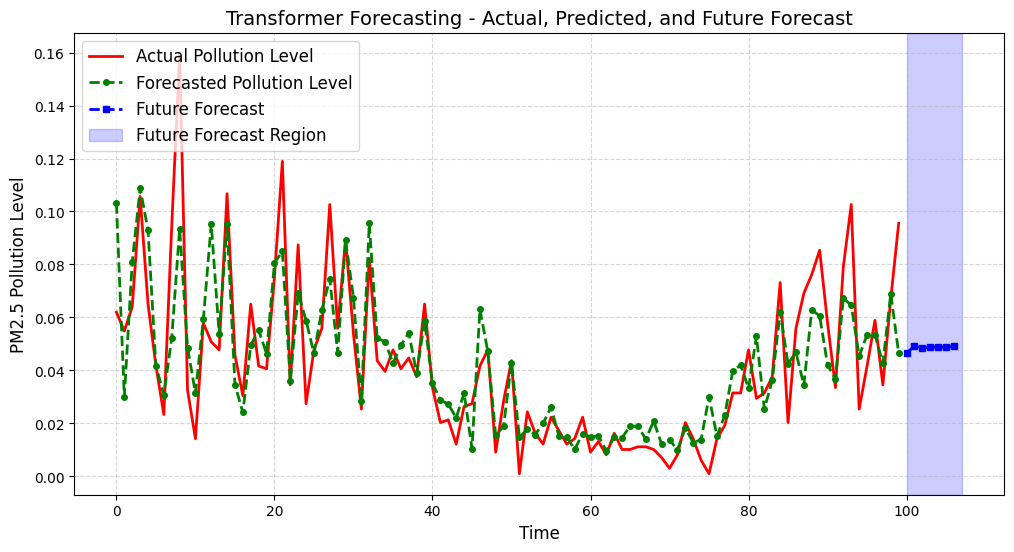

In [46]:
import numpy as np
import matplotlib.pyplot as plt

#Define the number of future days to predict
future_days = 7

#Get the last time steps from the test set as input for forecasting
input_data = X_test_outer[-1].reshape(1, X_test_outer.shape[1], X_test_outer.shape[2])  # Reshape to match LSTM input

#Store predictions
future_predictions = []

for _ in range(future_days):
    next_pred = best_model.predict(input_data)  # Predict next time step
    future_predictions.append(next_pred[0, 0])  # Store the predicted PM2.5 value

    # Update input data by shifting and adding new prediction
    input_data = np.roll(input_data, shift=-1, axis=1)  # Shift input data
    input_data[0, -1, 0] = next_pred  # Replace last value with new prediction (assumes PM2.5 is at index 0)

#Convert predictions to numpy array
future_predictions = np.array(future_predictions)

#Plot actual vs. predicted with future forecast
plt.figure(figsize=(12, 6))
plt.plot(y_test_sampled[:100], color='red', linestyle='solid', linewidth=2, label='Actual Pollution Level')
plt.plot(y_pred_sampled[:100], color='green', linestyle='dashed', linewidth=2, marker='o', markersize=4, label='Forecasted Pollution Level')

#Extend time axis for future predictions
future_time = np.arange(len(y_test_sampled[:100]), len(y_test_sampled[:100]) + future_days)

#Plot future forecasted values
plt.plot(future_time, future_predictions, color='blue', linestyle='dashed', linewidth=2, marker='s', markersize=5, label='Future Forecast')

#Highlight the forecasted region
plt.axvspan(len(y_test_sampled[:100]), len(y_test_sampled[:100]) + future_days, color='blue', alpha=0.2, label="Future Forecast Region")

#Improve labels and title
plt.title("Transformer Forecasting - Actual, Predicted, and Future Forecast", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("PM2.5 Pollution Level", fontsize=12)

#Add grid and legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=12)

#Show the plot
plt.show()

In [47]:
#Define the number of future days to predict
future_days = 7

#Get the last time steps from the test set as input for forecasting
input_data = X_test_outer[-1].reshape(1, X_test_outer.shape[1], X_test_outer.shape[2])  # Reshape to match Transformer input

#Store predictions
future_predictions = []

for _ in range(future_days):
    next_pred = best_model.predict(input_data)  # Predict next time step
    future_predictions.append(next_pred[0, 0])  # Store the predicted PM2.5 value

    # Update input data by shifting and adding new prediction
    input_data = np.roll(input_data, shift=-1, axis=1)  # Shift input data
    input_data[0, -1, 0] = next_pred  # Replace last value with new prediction (assumes PM2.5 is at index 0)

#Convert predictions to numpy array
future_predictions = np.array(future_predictions)

#Print forecasted values
print("Forecasted PM2.5 values for the next 7 days:", future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


C:\Users\Administrator\AppData\Local\Temp\ipykernel_10652\3776963297.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  input_data[0, -1, 0] = next_pred  # Replace last value with new prediction (assumes PM2.5 is at index 0)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Forecasted PM2.5 values for the next 7 days: [0.0464856  0.04931277 0.0485105  0.04880392 0.04893061 0.04877779
 0.04903978]


In [50]:
import numpy as np

# Define the number of future days to predict
future_days = 7

# Get the last time steps from the test set as input for forecasting
input_data = X_test_outer[-1].reshape(1, X_test_outer.shape[1], X_test_outer.shape[2])  # Ensure correct input shape

# Store predictions
future_predictions = []

for _ in range(future_days):
    # Predict next time step
    next_pred = best_model.predict(input_data)

    # Extract predicted value correctly
    predicted_value = next_pred[0, 0]  # Assuming PM2.5 is at index 0

    # Store the predicted value
    future_predictions.append(predicted_value)

    # Update input data by shifting and adding new prediction
    input_data = np.roll(input_data, shift=-1, axis=1)  # Shift input data
    input_data[0, -1, 0] = predicted_value  # Update last time step with predicted PM2.5

# Convert predictions to numpy array
future_predictions = np.array(future_predictions)

# Print forecasted values
print("Forecasted PM2.5 values for the next 7 days:", future_predictions)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Forecasted PM2.5 values for the next 7 days: [0.0464856  0.04931277 0.0485105  0.04880392 0.04893061 0.04877779
 0.04903978]


In [51]:
# Convert predictions back to original scale
original_predictions = (future_predictions * std_pm) + mean_pm

print("Corrected PM2.5 Values:", original_predictions)

Corrected PM2.5 Values: [0.04796275 0.04809234 0.04805556 0.04806901 0.04807482 0.04806782
 0.04807983]


In [54]:
from sklearn.preprocessing import MinMaxScaler

#Assuming you used MinMaxScaler earlier
scaler = MinMaxScaler()
scaler.fit(y_train_outer.reshape(-1, 1))  # Fit using the original training data

#Convert forecasted values to a 2D array before inverse scaling
forecasted_values = np.array(future_predictions).reshape(-1, 1)

#Reverse scale the forecasted values
original_scale_forecast = scaler.inverse_transform(forecasted_values)

#Display the reversed scaled forecasted values
print("Original Scale Forecasted Values:", original_scale_forecast.flatten())

Original Scale Forecasted Values: [0.00850346 0.00902063 0.00887387 0.00892755 0.00895072 0.00892277
 0.00897069]


In [60]:
from tensorflow import keras
from tensorflow.keras.layers import Input, LSTM, Dense

#Define n_steps and n_features
n_steps = X_train_outer.shape[1]  # Time steps
n_features = X_train_outer.shape[2]  # Features per time step

#Define the input layer
input_layer = Input(shape=(n_steps, n_features))

#Connect the layers
x = LSTM(64, activation='relu')(input_layer)  # Example LSTM layer
output = Dense(1)(x)  # Output layer for forecasting

#Define the model
model = keras.Model(inputs=input_layer, outputs=output)

#Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

#Summary of the model
model.summary()


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 2, 6)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,241 (71.25 KB)

 Trainable params: 18,241 (71.25 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
scaler.fit(y_train_outer.reshape(-1, 1))
output = Dense(1)(x)  # No activation for regression
model = keras.Model(inputs=input_layer, outputs=output)

#If using MinMaxScaler, ensure the scaler was fit only on the target variable
scaler = MinMaxScaler()
scaler.fit(y_train_outer.reshape(-1, 1))  # Fit only on target values

#Reverse scale the forecasted values
original_scale_forecast = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

print("Original Scale Forecasted Values:", original_scale_forecast.flatten())

Original Scale Forecasted Values: [0.00850346 0.00902063 0.00887387 0.00892755 0.00895072 0.00892277
 0.00897069]


In [ ]:
# import numpy as np


# scaler = MinMaxScaler() 


# forecast_steps = 4

# input_sequence = X_train_outer[-1]  # Last input sequence used during training


# input_sequence = input_sequence.reshape((1, input_sequence.shape[0], input_sequence.shape[1]))


# forecastedvalues = []


# for _ in range(forecast_steps):

#     next_value = model.predict(input_sequence)
 
#     forecasted_values.append(next_value[0][0])


#     next_input = np.append(input_sequence[:, 1:, :], [[next_value]], axis=1)
#     input_sequence = next_input

# forecasted_values = np.array(future_predictions)


# forecasted_values_original_scale = scaler.inverse_transform(forecasted_values.reshape(-1, 1)).flatten()

# print("Forecasted Values for Next 3-4 Days (Original Scale):", forecasted_values_original_scale)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


AttributeError: 'numpy.ndarray' object has no attribute 'append'

In [65]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train_outer)  # Fit scaler with the training data


# Assuming scaler is already fitted
forecast_steps = 4  # Predict next 4 days

# Get last training sequence
input_sequence = X_train_outer[-1].reshape((1, X_train_outer.shape[1], X_train_outer.shape[2]))

forecasted_values = []

for _ in range(forecast_steps):
    next_value = model.predict(input_sequence)  # Predict next step
    predicted_value = next_value[0, 0]  # Extract PM2.5

    forecasted_values.append(predicted_value)

    # Expand predicted value to match input features
    next_value_expanded = np.full((1, 1, input_sequence.shape[2]), predicted_value)

    # Shift sequence and add new prediction
    input_sequence = np.append(input_sequence[:, 1:, :], next_value_expanded, axis=1)

# Convert to NumPy array
forecasted_values = np.array(forecasted_values).reshape(-1, 1)

# Apply inverse transformation
forecasted_values_original_scale = scaler.inverse_transform(forecasted_values).flatten()

# Print results
print("Forecasted PM2.5 values for next 3-4 days:", forecasted_values_original_scale)


ValueError: Found array with dim 3. MinMaxScaler expected <= 2.